In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Cargar el archivo CSV ya procesado
e1 = pd.read_csv('/Users/alejandrabenavidessanclemente/Desktop/ProyectoGradoGEB/modelos/datos_procesados_empresa1.csv')

In [3]:
# Convertir EFFECTIVE_DATE a formato de fecha si no está hecho previamente
e1["EFFECTIVE_DATE"] = pd.to_datetime(e1["EFFECTIVE_DATE"], errors='coerce')

# Ordenar el DataFrame por la fecha
e1_sorted = e1.sort_values(by="EFFECTIVE_DATE")

In [4]:
# Crear una carpeta para guardar las imágenes si no existe
output_folder = "gráficas_diarias_ppt"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [ ]:
# Obtener los años únicos en el DataFrame
years = e1_sorted['EFFECTIVE_DATE'].dt.year.unique()

# Recorrer el archivo secuencialmente por año
for year in years:
    # Filtrar los datos por año
    e1_year = e1_sorted[e1_sorted['EFFECTIVE_DATE'].dt.year == year]
    
    # Obtener los días únicos ordenados dentro del año
    days = sorted(e1_year['EFFECTIVE_DATE'].dt.date.unique())
    
    for day in days:
        # Filtrar los datos por día
        e1_day = e1_year[e1_year['EFFECTIVE_DATE'].dt.date == day]
        
        # Extraer la señal del día
        signal_day = e1_day['ORIG_RAW_VOLUME'].values
        
        # Graficar la variable para ese día
        plt.figure(figsize=(10, 6))
        plt.plot(e1_day['EFFECTIVE_DATE'], signal_day, label="ORIG_RAW_VOLUME", color='b', alpha=0.7)
        
        # Ajustes en la gráfica
        plt.title(f"Comportamiento de ORIG_RAW_VOLUME - Año {year} - Día {day}", fontsize=14, fontweight="bold")
        plt.xlabel("Fecha", fontsize=12)
        plt.ylabel("ORIG_RAW_VOLUME", fontsize=12)
        plt.grid(True)
        plt.xticks(rotation=45)
        
        # Guardar la imagen en la carpeta específica
        filename = f"ORIG_RAW_VOLUME_{year}_{day}.png"
        filepath = os.path.join(output_folder, filename)
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
        plt.close()
print(f"Gráficas guardadas en {filepath}")

Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-03.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-04.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-05.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-06.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-07.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-08.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-09.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-10.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-11.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-12.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-13.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-14.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUME_2018_2018-09-15.png
Gráfica guardada en gráficas_diarias/ORIG_RAW_VOLUM

In [10]:
from datetime import datetime

# Definir el rango específico de fechas
start_date = datetime(2021, 3, 28)
end_date = datetime(2021, 4, 24)

# Filtrar datos dentro del rango
e1_filtered = e1_sorted[(e1_sorted['EFFECTIVE_DATE'] >= start_date) &
                        (e1_sorted['EFFECTIVE_DATE'] <= end_date)]

# Obtener días únicos ordenados
days = sorted(e1_filtered['EFFECTIVE_DATE'].dt.date.unique())

# Graficar por día
for day in days:
    e1_day = e1_filtered[e1_filtered['EFFECTIVE_DATE'].dt.date == day]
    signal_day = e1_day['ORIG_RAW_VOLUME'].values

    plt.figure(figsize=(10, 6))
    plt.plot(e1_day['EFFECTIVE_DATE'], signal_day, label="ORIG_RAW_VOLUME", color='b', alpha=0.7)

    # Ajustes de la gráfica
    plt.title(f"Comportamiento de ORIG_RAW_VOLUME - Día {day}", fontsize=14, fontweight="bold")
    plt.xlabel("Fecha", fontsize=12)
    plt.ylabel("ORIG_RAW_VOLUME", fontsize=12)
    plt.ylim(-1.5, 1.5)  # Estandarizar eje Y
    plt.grid(True)
    plt.xticks(rotation=45)

    # Guardar imagen
    filename = f"ORIG_RAW_VOLUME_2021_{day}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()

print(f"Gráficas guardadas en {output_folder}")

Gráficas guardadas en gráficas_diarias_ppt


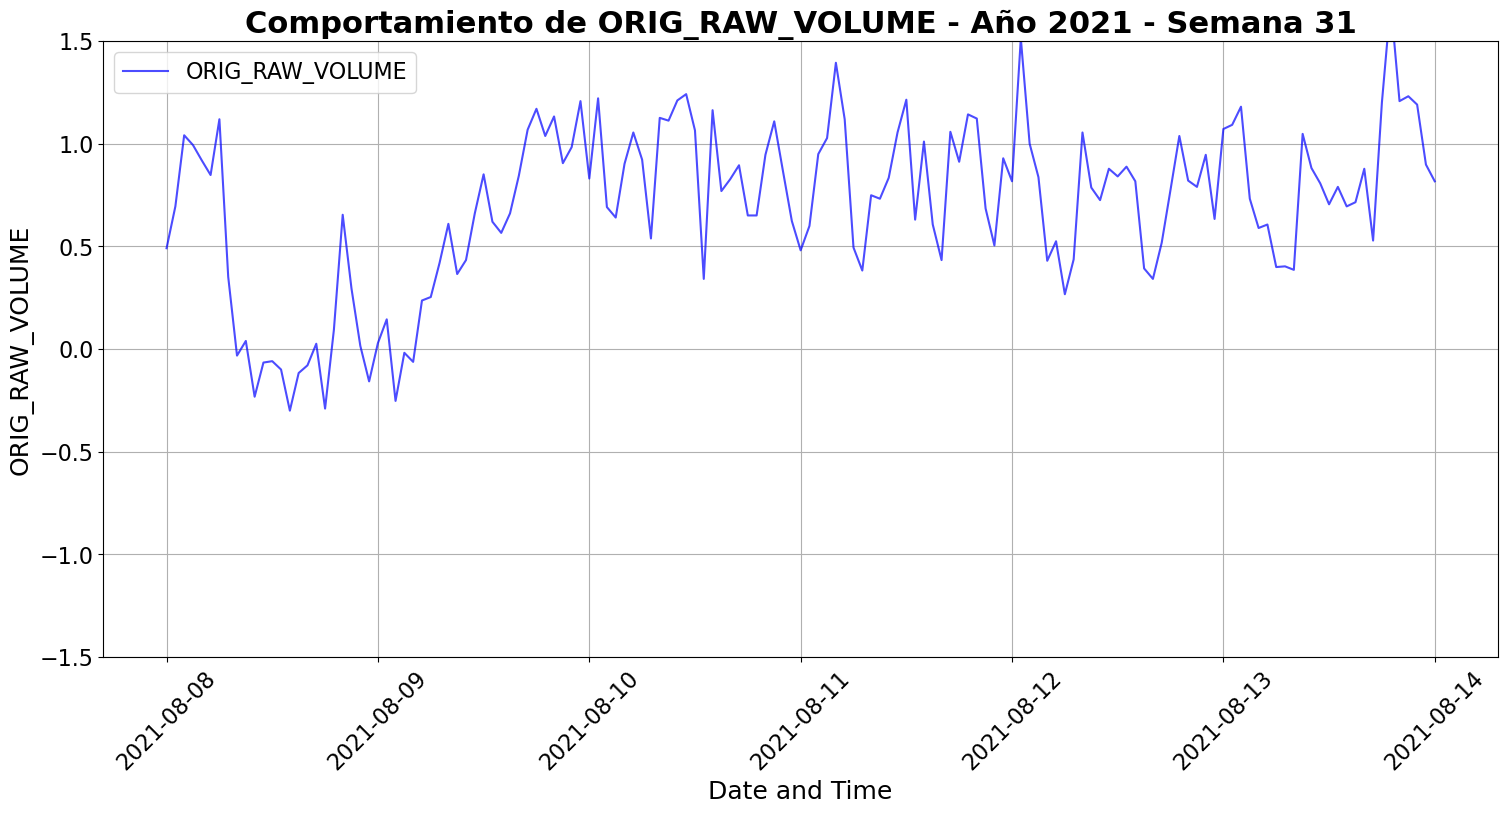

In [21]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Asegurarse de que EFFECTIVE_DATE es datetime
e1_sorted['EFFECTIVE_DATE'] = pd.to_datetime(e1_sorted['EFFECTIVE_DATE'])

# Definir el rango semanal
start_date = pd.to_datetime("2021-08-08")
end_date = pd.to_datetime("2021-08-14")

# Filtrar los datos para la semana
e1_week = e1_sorted[(e1_sorted['EFFECTIVE_DATE'] >= start_date) &
                    (e1_sorted['EFFECTIVE_DATE'] <= end_date)]

# Extraer la señal y las fechas
signal_week = e1_week['ORIG_RAW_VOLUME'].values
time_week = e1_week['EFFECTIVE_DATE']

# Generar gráfica semanal
plt.figure(figsize=(18, 8))  # Tamaño más grande
plt.plot(time_week, signal_week, label="ORIG_RAW_VOLUME", color='b', alpha=0.7)

# Títulos y etiquetas en inglés con mayor tamaño de fuente
plt.title("Comportamiento de ORIG_RAW_VOLUME - Año 2021 - Semana 31", fontsize=22, fontweight="bold")
plt.xlabel("Date and Time", fontsize=18)
plt.ylabel("ORIG_RAW_VOLUME", fontsize=18)

# Ejes y leyenda con fuente grande
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Asegurarse de que EFFECTIVE_DATE es datetime
e1_sorted['EFFECTIVE_DATE'] = pd.to_datetime(e1_sorted['EFFECTIVE_DATE'])

# Definir el rango de fechas
start_date = pd.to_datetime("2023-09-10")
end_date = pd.to_datetime("2023-09-16")

# Generar una gráfica por cada día en el rango
for single_date in pd.date_range(start=start_date, end=end_date):
    day_start = single_date
    day_end = single_date + pd.Timedelta(days=1)

    # Filtrar datos del día
    e1_day = e1_sorted[(e1_sorted['EFFECTIVE_DATE'] >= day_start) &
                       (e1_sorted['EFFECTIVE_DATE'] < day_end)]

    if e1_day.empty:
        print(f"No data for {single_date.date()}, skipping...")
        continue

    # Extraer datos
    signal_day = e1_day['ORIG_RAW_VOLUME'].values
    time_day = e1_day['EFFECTIVE_DATE']

    # Crear la gráfica
    plt.figure(figsize=(20, 10))  # Gráfica aún más grande
    plt.plot(time_day, signal_day, label="ORIG_RAW_VOLUME", color='b', alpha=0.7)

    # Título y etiquetas en inglés con fuente extra grande
    date_str = single_date.strftime("%B %d, %Y")
    filename_date = single_date.strftime("%Y_%m_%d")
    plt.title(f"ORIG_RAW_VOLUME Behavior - {date_str}", fontsize=28, fontweight="bold")
    plt.xlabel("Date and Time", fontsize=24)
    plt.ylabel("ORIG_RAW_VOLUME", fontsize=24)

    plt.ylim(-1.6, 2)
    plt.grid(True)
    plt.xticks(rotation=45, fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)

    # Guardar archivo
    filename = f"ORIG_RAW_VOLUME_{filename_date}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Graph saved for {date_str} at: {filepath}")

Graph saved for September 10, 2023 at: graficas_septiembre/ORIG_RAW_VOLUME_2023_09_10.png
Graph saved for September 11, 2023 at: graficas_septiembre/ORIG_RAW_VOLUME_2023_09_11.png
Graph saved for September 12, 2023 at: graficas_septiembre/ORIG_RAW_VOLUME_2023_09_12.png
Graph saved for September 13, 2023 at: graficas_septiembre/ORIG_RAW_VOLUME_2023_09_13.png
Graph saved for September 14, 2023 at: graficas_septiembre/ORIG_RAW_VOLUME_2023_09_14.png
Graph saved for September 15, 2023 at: graficas_septiembre/ORIG_RAW_VOLUME_2023_09_15.png
Graph saved for September 16, 2023 at: graficas_septiembre/ORIG_RAW_VOLUME_2023_09_16.png


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import os
import pandas as pd

# Asegurarse de que EFFECTIVE_DATE es datetime
e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])

# Definir rango de fechas
start_date = pd.to_datetime("2023-09-10")
end_date = pd.to_datetime("2023-09-16")

# Crear carpeta de salida
output_folder = "graficas_septiembre"
os.makedirs(output_folder, exist_ok=True)

# Definir escalas para la transformada Wavelet
scales = np.arange(1, 128)

# Iterar por cada día dentro del rango
for current_date in pd.date_range(start=start_date, end=end_date):
    next_day = current_date + pd.Timedelta(days=1)

    # Filtrar datos del día
    df_day = e1_filtered[(e1_filtered['EFFECTIVE_DATE'] >= current_date) &
                         (e1_filtered['EFFECTIVE_DATE'] < next_day)]

    if df_day.empty:
        print(f"No data for {current_date.date()}, skipping...")
        continue

    # Extraer la señal
    signal_day = df_day['ORIG_RAW_VOLUME'].values

    # Aplicar la Transformada Wavelet Continua
    coefficients, frequencies = pywt.cwt(signal_day, scales, 'morl')

    # Crear la figura
    plt.figure(figsize=(18, 8))
    img =plt.imshow(np.abs(coefficients), aspect='auto', cmap='jet',
               extent=[0, len(signal_day), scales[-1], scales[0]])

    # Título y etiquetas en inglés
    date_str = current_date.strftime("%B %d, %Y")
    filename_date = current_date.strftime("%Y_%m_%d")
    plt.title(f"Wavelet Scalogram - {date_str}", fontsize=24, fontweight="bold")
    plt.xlabel("Time (Hour Index)", fontsize=18)
    plt.ylabel("Scale", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Add colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Magnitude", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    # Guardar la imagen
    filename = f"wavelet_scalogram_{filename_date}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Wavelet saved for {date_str} at: {filepath}")

No data for 2023-09-10, skipping...
No data for 2023-09-11, skipping...
No data for 2023-09-12, skipping...
No data for 2023-09-13, skipping...
No data for 2023-09-14, skipping...
No data for 2023-09-15, skipping...
No data for 2023-09-16, skipping...


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import os
import pandas as pd

# Asegurar tipo datetime
e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])

# Crear carpeta de salida
output_folder = "wavelet_weekly"
os.makedirs(output_folder, exist_ok=True)

# Rango de semanas a procesar
weeks = {
    "September_10_16": ("2023-09-10", "2023-09-17"),
    "December_10_16": ("2023-12-10", "2023-12-17"),
}

# Escalas para la Transformada Wavelet
scales = np.arange(1, 128)

for label, (start_str, end_str) in weeks.items():
    start_date = pd.to_datetime(start_str)
    end_date = pd.to_datetime(end_str)

    # Filtrar datos de la semana
    df_week = e1_filtered[(e1_filtered['EFFECTIVE_DATE'] >= start_date) &
                          (e1_filtered['EFFECTIVE_DATE'] < end_date)]

    if df_week.empty:
        print(f"No data for week {label}, skipping...")
        continue

    # Extraer señal concatenada de toda la semana
    signal_week = df_week['ORIG_RAW_VOLUME'].values

    # Aplicar la Transformada Wavelet Continua
    coefficients, frequencies = pywt.cwt(signal_week, scales, 'morl')

    # Crear la figura
    plt.figure(figsize=(18, 8))
    img = plt.imshow(np.abs(coefficients), aspect='auto', cmap='jet',
                     extent=[0, len(signal_week), scales[-1], scales[0]])

    # Título y etiquetas
    plt.title(f"Wavelet Scalogram - Week of {label.replace('_', ' ')}", fontsize=24, fontweight="bold")
    plt.xlabel("Time (Index of measurements)", fontsize=18)
    plt.ylabel("Scale", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Add colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Magnitude", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    # Guardar la imagen
    filename = f"wavelet_scalogram_{label}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Wavelet saved for {label} at: {filepath}")

NameError: name 'e1_filtered' is not defined